In [21]:
%reload_ext autoreload
%autoreload 2

import pickle
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import json
from scipy import interpolate

import sys
sys.path.append("..")

from utils.validation import roc_finite_sample_band

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# Coverage

In [59]:
run_name = 'hmc_Dgpsfix_s1k_Mkmaxfix_s1k'
z = pickle.load(open(f'../outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'])


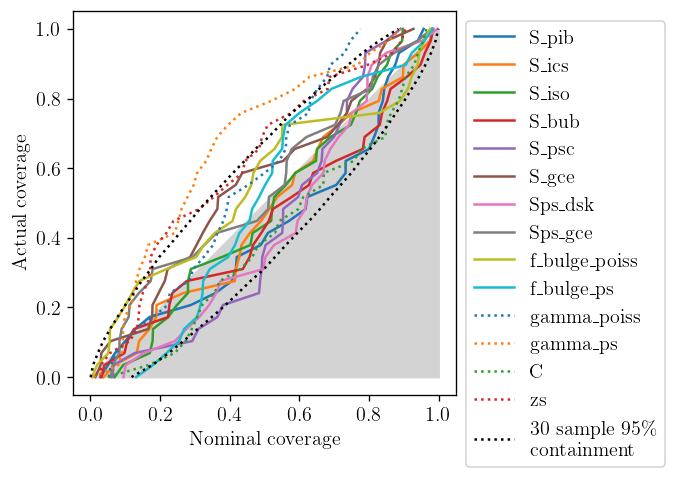

In [16]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_psc', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
# labels = [
#     'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_blg', 'S_nfw', 'Sps_nfw', 'Sps_blg', 'Sps_dsk',
#     'gamma_poiss', 'gamma_ps', 'C', 'zs'
# ]
# z['S_gce'] = ([0,0.5], [0.5, 1])
# z['f_bulge_poiss'] = ([0,0.6], [0.6, 1])
probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
# plt.savefig('tmp.pdf')

# Corner

In [5]:
from utils.multi_corner import multi_corner
import json

In [ ]:
labels = ['Sps_dsk', 'Sps_nfw', 'Sps_blg']
s_in = {}
labels_dict = {}
colors_dict = {}
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    nskey = str(x)
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    s_in[nskey] = {k: s[k] for k in labels}
    labels_dict[nskey] = nskey
    colors_dict[nskey] = 'gray'

truth_dict = json.load(open('truth_dict_gcfull.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

# Marginal posterior

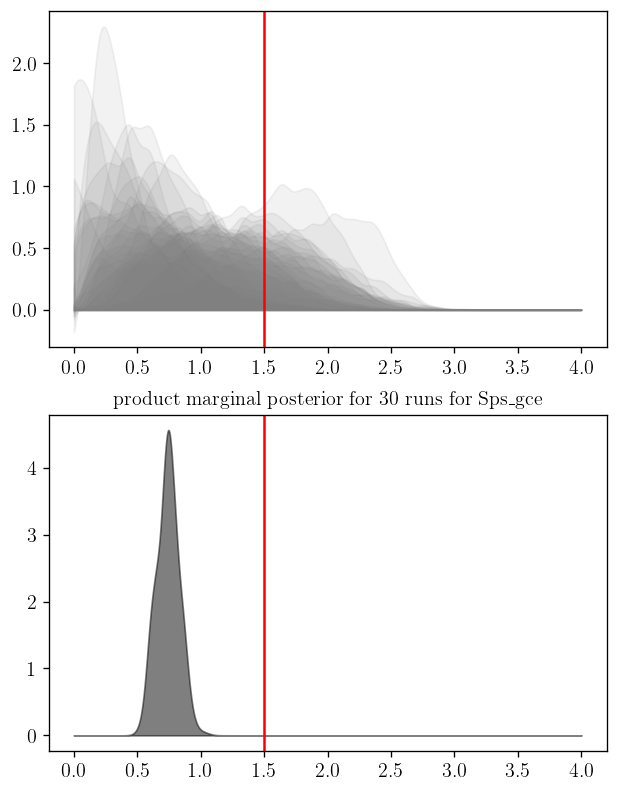

In [37]:
run_name = 'hmc_Dgpsfix_s1k_Mkmaxfix_s1k'
# run_name = 'hmc_Dbase230927new_Mbase230927'

truth_dict = json.load(open(f'truth_dict_base230927.json', 'r'))
k = 'Sps_gce'
n_run = 30

prior_dict = json.load(open(f'prior_dict_base230927.json', 'r'))
n_bins = 50
n_bins_sr = 1000
bin_edges = np.linspace(*prior_dict[k], n_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers_sr = np.linspace(*prior_dict[k], n_bins_sr)

fig, axs = plt.subplots(2, 1, figsize=(6, 8))

pdf_tot = np.ones(n_bins_sr)
for i, x in enumerate(range(n_run)):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{x}_n10000_ns0.p', 'rb'))
    pdf, _ = np.histogram(s[k], bins=bin_edges)
    pdf_sr = interpolate.CubicSpline(bin_centers, pdf, extrapolate=True)(bin_centers_sr)
    pdf_sr /= np.trapz(pdf_sr, bin_centers_sr)
    axs[0].fill_between(bin_centers_sr, pdf_sr, 0, color='gray', alpha=0.1)

    pdf_tot *= pdf_sr
    pdf_tot /= np.trapz(pdf_tot, bin_centers_sr)

axs[1].fill_between(bin_centers_sr, pdf_tot, 0, color='k', alpha=0.5)

axs[0].axvline(truth_dict[k], color='red')
axs[1].axvline(truth_dict[k], color='red')
axs[1].set(title=f'product marginal posterior for {n_run} runs for {k}');

# Data

In [14]:
data_s = np.load('../outputs/sims/sim_s1k_n100.npy')
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')
data_full = np.zeros((data_s.shape[0], len(mask_roi)))
data_full[:, ~mask_norm] = data_s
data_full[:, mask_roi] = 0

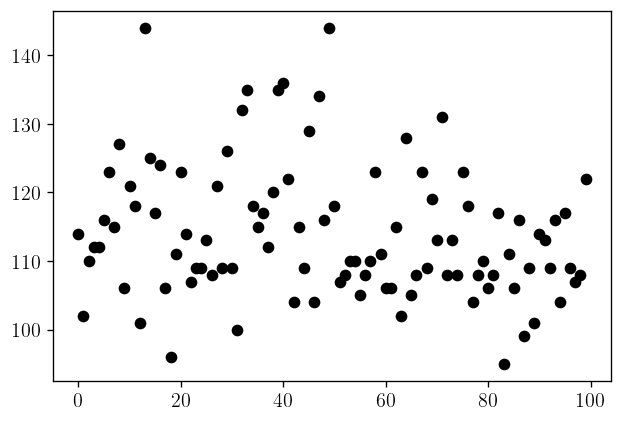

In [15]:
plt.plot(data_full.max(axis=1), 'ko')

# View data

In [43]:
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')

def plot_data(ax, data, **kwargs):
    if len(data) < mask_norm.shape[0]:
        data_full = np.zeros(mask_norm.shape[0])
        data_full[~mask_norm] = data
    else:
        data_full = data
    plt.sca(ax)
    hp.cartview(data_full, lonra=[-25, 25], latra=[-25, 25], hold=True, **kwargs)

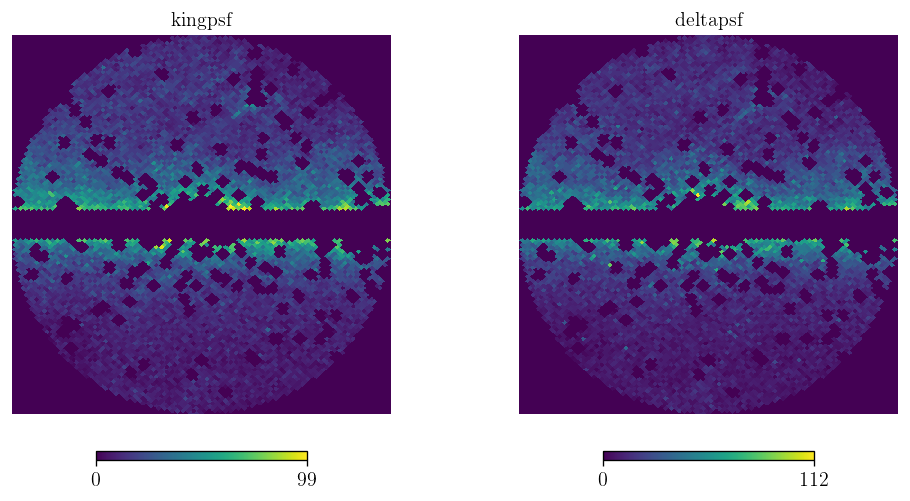

In [15]:
data0 = np.load('../outputs/sims/base1023_fexp_n100.npy')[0]
data1 = np.load('../outputs/sims/base1023_fexp_deltapsf_n100.npy')[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], data0, title='kingpsf')
plot_data(axs[1], data1, title='deltapsf')

In [40]:
from models.np_model import NPModel
m = NPModel(data=np.zeros(mask_norm.shape[0]))

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 0.0


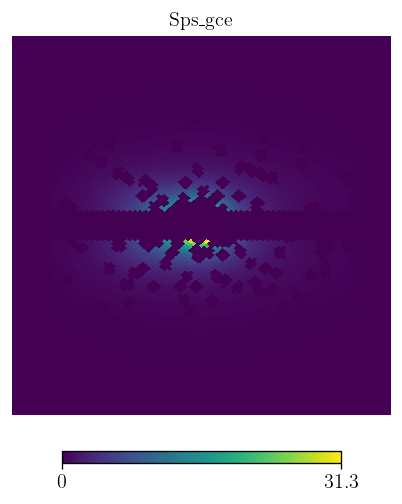

In [58]:
truth_dict = json.load(open('truth_dict_base230927new.json', 'r'))
temp_nfw = m.nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps'])
temp_nfw /= np.mean(temp_nfw[~mask_norm])
temp_blg = m.bulge_templates[1]
temp_blg /= np.mean(temp_blg[~mask_norm])
f = truth_dict['f_bulge_ps']
temp = f * temp_blg + (1 - f) * temp_nfw

temp = np.array(temp)
temp[mask_roi] = 0

fig, axs = plt.subplots(1, 1, figsize=(6, 5))
plot_data(axs, temp, title='Sps_gce')

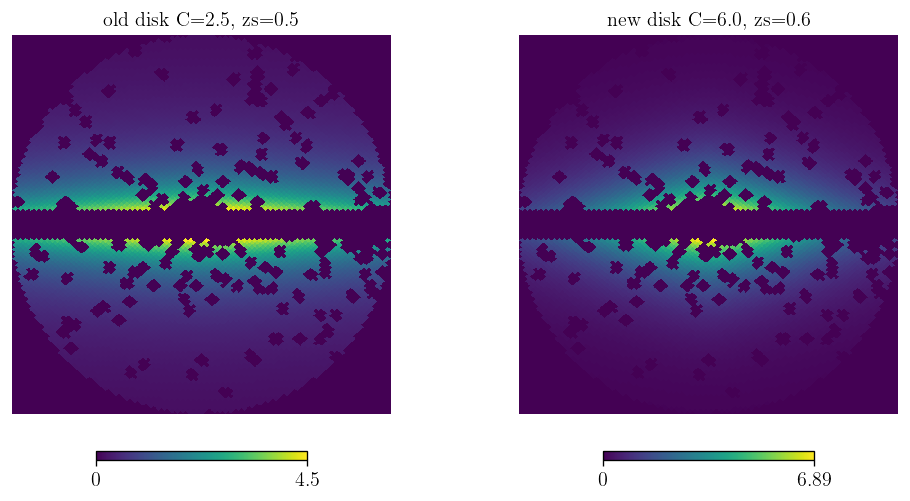

In [46]:
truth_dict = json.load(open('truth_dict_base230927.json', 'r'))
temp_ps_dsk = m.disk_template.get_template(zs=truth_dict['zs'], C=truth_dict['C'])
temp_ps_dsk = np.array(temp_ps_dsk)
temp_ps_dsk /= np.mean(temp_ps_dsk[~mask_norm])

truth_dict2 = json.load(open('truth_dict_base230927new.json', 'r'))
temp_ps_dsk2 = m.disk_template.get_template(zs=truth_dict2['zs'], C=truth_dict2['C'])
temp_ps_dsk2 = np.array(temp_ps_dsk2)
temp_ps_dsk2 /= np.mean(temp_ps_dsk2[~mask_norm])

temp_ps_dsk[mask_roi] = 0
temp_ps_dsk2[mask_roi] = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], temp_ps_dsk, title=f'old disk C={truth_dict["C"]}, zs={truth_dict["zs"]}')
plot_data(axs[1], temp_ps_dsk2, title=f'new disk C={truth_dict2["C"]}, zs={truth_dict2["zs"]}')

# Compare truth

In [2]:
truth_dict_old = json.load(open('truth_dict_base230927.json', 'r'))
truth_dict_new = json.load(open('truth_dict_base230927new.json', 'r'))
prior_dict = json.load(open('prior_dict_base230927.json', 'r'))

In [4]:
print(f'{"name":12} {"old":>10} {"new":>10}    {"prior"}')
for k in truth_dict_new.keys():
    if isinstance(truth_dict_old[k], list):
        lo = [int(x) for x in truth_dict_old[k]]
        ln = [int(x) for x in truth_dict_new[k]]
        print(f'{k:12} {str(lo):>10} {str(ln):>10}    {prior_dict[k]}')
    else:
        print(f'{k:12} {truth_dict_old[k]:10.1f} {truth_dict_new[k]:10.1f}    {prior_dict[k]}')

name                old        new    prior
S_pib              10.0       11.2    [0.001, 14]
theta_pib     [1, 0, 0]  [1, 0, 0]    Dirichlet
S_ics               6.0        6.5    [0.001, 14]
theta_ics     [1, 0, 0]  [1, 0, 0]    Dirichlet
S_bub               0.2        1.4    [0.001, 5]
S_iso               0.3        0.4    [0.001, 5]
S_psc               0.5        2.7    [0.001, 5]
S_gce               1.0        0.6    [1e-05, 4]
f_bulge_poiss        0.2        0.2    [0, 1]
theta_bulge_poiss [1, 0, 0, 0, 0] [0, 0, 0, 0, 1]    Dirichlet
gamma_poiss         0.9        1.0    [0.2, 2.0]
Sps_gce             1.5        1.0    [0.001, 4]
n1_gce              5.5        5.0    [4.0, 6.0]
n2_gce              1.5        1.0    [0.5, 1.99]
n3_gce             -5.5       -5.5    [-6.0, -5.0]
sb1_gce             7.6       10.0    [5.0, 40.0]
lambdas_gce         0.3        0.4    [0.1, 0.95]
f_bulge_ps          0.3        0.8    [0, 1]
theta_bulge_ps [0, 1, 0, 0, 0] [0, 0, 0, 0, 1]    Dirichlet
ga

In [15]:
from itertools import cycle

def show_interval_and_values(ax, y, interval, values, normalize=False):
    cc = cycle(plt.rcParams['axes.prop_cycle'])
    if normalize:
        values = [(v - interval[0]) / (interval[1] - interval[0]) for v in values]
        interval = [0, 1]
    interval_style = dict(color='k', lw=2)
    ax.plot(interval, [y, y], **interval_style)
    ax.plot([interval[0], interval[0]], [y-0.1, y+0.1], **interval_style)
    ax.plot([interval[1], interval[1]], [y-0.1, y+0.1], **interval_style)
    for v in values:
        ax.plot(v, y, marker='o', **next(cc))

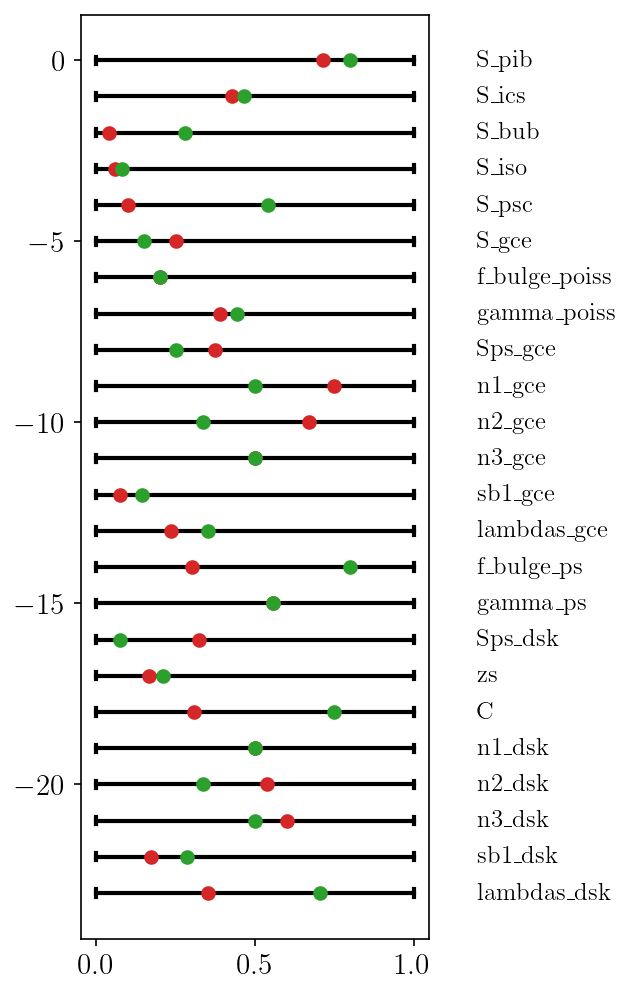

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(3, 8))
ax = axs
y = 0
for k in truth_dict_new.keys():
    if not isinstance(truth_dict_old[k], list):
        show_interval_and_values(ax, y, prior_dict[k], [truth_dict_old[k], truth_dict_new[k]], normalize=True)
        ax.text(1.2, y, k, ha='left', va='center')
        y -= 1